## P(X) integration test


In this notebook we will integrate the density probability function $P(\widetilde{X})$ using two approach: 

1. Integrate in a hypervolume of 6 variables 

2. Integrate the positions ($x$,$y$,$z$) in a sphere and the velocities ($v_x$,$v_y$,$v_z$) in a cube

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_X_to_E, 
    compute_jacobian_XoE,
    trasformation_E_to_X, 
    computeNumericalJacobian,
)
import numpy as np
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
import spiceypy as spy
import seaborn as sns
import plotly.graph_objects as go


In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

### Veryfing CMND fit 

C:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\jacobian_calculations\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


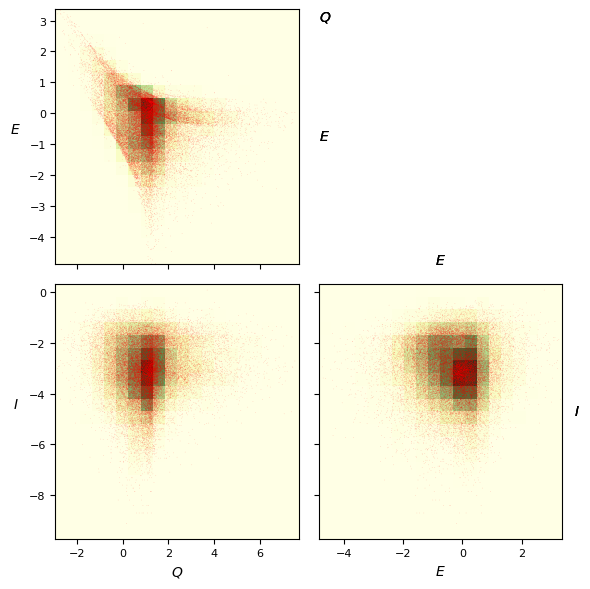

In [3]:
F = mm.FitCMND(f"../../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [4]:
def P_E_CMND(a: float, e: float, i: float, F: mm.FitCMND) -> float:
    max = 2*np.pi; min = 0

    q = a*(1-e)
    element = np.array([q, e, i])
    scales=[1.35,1.00,np.pi]
    u_element = mm.Util.tIF(element, scales, mm.Util.f2u)

    P_qei = F.cmnd.pdf(u_element)
    P_WwM = 1/(max - min)**3

    return P_qei * P_WwM

In [5]:
def Jacobian_qei_to_QEI(q: float, e: float, i: float, q_max: float, e_max: float, i_max: float) -> np.array:
    partialA_a = q_max/(q*(q_max - q))
    partialA_e = 0
    partialA_i = 0
    partialE_a = 0
    partialE_e = e_max/(e*(e_max - e))
    partialE_i = 0
    partialI_a = 0
    partialI_e = 0
    partialI_i = i_max/(i*(i_max - i))

    Jacobian = np.array([
        [partialA_a, partialA_e, partialA_i], 
        [partialE_a, partialE_e, partialE_i], 
        [partialI_a, partialI_e, partialI_i]
        ])
        
    return Jacobian

In [6]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    neas_number = 0
    not_neas_number = 0

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        q = a*(1-e)
        if q > 1.35 or e > 1: 
            P.flat[idx] = 0
            neas_number += 1
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
                if det == 0 or not np.isfinite(det):
                    print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)
                    not_neas_number += 1

                    if np.isnan(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)):
                        print('Nan value encounter: ', P_E_CMND(a, e, i, F), abs(inv_det), abs(det_QEI))
                        print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    
    return P.reshape(shape)

In [7]:
N = int(1e7)
fit_sample = F.cmnd.rvs(Nsam=N)

In [8]:
scales=[1.35,1.00,np.pi]
converted_sample = np.zeros_like(fit_sample)
for i, element in enumerate(fit_sample):
    converted_sample[i] = mm.Util.tIF(element, scales, mm.Util.u2f)

converted_sample

array([[0.7013704 , 0.5093252 , 0.50446059],
       [1.09328971, 0.23117789, 0.29883663],
       [0.7709682 , 0.37018422, 0.40898496],
       ...,
       [0.83073578, 0.26471134, 0.28173683],
       [1.14224078, 0.58420804, 0.05075767],
       [0.84161524, 0.57732545, 0.04780683]], shape=(10000000, 3))

In [9]:
q_CMND = converted_sample[:,0]
e_CMND = converted_sample[:,1]
i_CMND = converted_sample[:,2]

Omega_uniform = np.random.uniform(0, 2*np.pi, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)

elements = np.column_stack((q_CMND, e_CMND, i_CMND, Omega_uniform, w_uniform, M_uniform))

state_vectors = np.zeros((N, 6))
for el in tqdm(range(N)):
    q = q_CMND[el]
    e = e_CMND[el]
    i = i_CMND[el]
    Omega = Omega_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]
    a = q/(1-e)

    x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
    state_vectors[el] = np.array([x, y, z, vx, vy, vz])

100%|██████████| 10000000/10000000 [03:30<00:00, 47395.99it/s]


### Integration in hypercube 

In [10]:
def hypercube_surface_integral_P_X_CMND(center, widths, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        max_elemetns: tuple/list/array of (a_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral

In [11]:
#max elements
max_elements = (1.35, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

In [12]:
v_y

6.2840227308020005

In [13]:
widths

(0.2, 0.2, 0.2, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)

In [14]:
#max elements
max_elements = (1.35, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = hypercube_surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=8, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 1698.0192692873645
Numerical (count) number of objects inside volume: 1776
Ratio 0.9560919309050476


### Integral in a sphere ($x$,$y$,$z$) and a in a cube in ($v_x$,$v_y$,$v_z$)

In [15]:
def sphere_surface_integral_P_X_CMND(
    c: np.array,
    r: float,
    v: np.array,
    dv: float,
    deg: int,
    q_max: float,
    e_max: float,
    i_max: float,
    mu: float,
    F: object
) -> float:
    """
    Calculates the 6D integral of P_X_CMND using Gauss-Legendre Quadrature.
    Robust to P_X_CMND returning extra diagnostic values.
    """
    from numpy.polynomial.legendre import leggauss
    # 1. Get Gauss-Legendre nodes and weights
    nodes, weights = leggauss(deg)

    # 2. Velocity Mesh (Cartesian Box)
    vx_vals = v[0] + dv * nodes
    vy_vals = v[1] + dv * nodes
    vz_vals = v[2] + dv * nodes
    
    # 3. Position Mesh (Spherical Coordinates)
    # rho: [0, r], theta: [0, pi], phi: [0, 2pi]
    rho_vals = (r / 2.0) * (nodes + 1)
    theta_vals = (np.pi / 2.0) * (nodes + 1)
    phi_vals = np.pi * (nodes + 1)

    # 4. Construct the 6D Meshgrid
    # Order: rho, theta, phi, vx, vy, vz
    Rho, Theta, Phi, Vx, Vy, Vz = np.meshgrid(
        rho_vals, theta_vals, phi_vals, vx_vals, vy_vals, vz_vals, indexing='ij'
    )
    
    # Mesh the weights
    W_rho, W_theta, W_phi, W_vx, W_vy, W_vz = np.meshgrid(
        weights, weights, weights, weights, weights, weights, indexing='ij'
    )

    # 5. Coordinate Transformations
    sin_theta = np.sin(Theta)
    cos_theta = np.cos(Theta)
    sin_phi = np.sin(Phi)
    cos_phi = np.cos(Phi)
    
    X = c[0] + Rho * sin_theta * cos_phi
    Y = c[1] + Rho * sin_theta * sin_phi
    Z = c[2] + Rho * cos_theta

    # 6. Calculate Integration Weights (Jacobians)
    scale_factors = (r / 2.0) * (np.pi / 2.0) * np.pi * (dv**3)
    spherical_jacobian = (Rho**2) * sin_theta
    
    total_weights = (
        W_rho * W_theta * W_phi * W_vx * W_vy * W_vz 
        * spherical_jacobian 
        * scale_factors
    )

    # 7. Evaluate Function
    P_output = P_X_CMND(
        X.ravel(), Y.ravel(), Z.ravel(), 
        Vx.ravel(), Vy.ravel(), Vz.ravel(),
        q_max, e_max, i_max, mu, F
    )
    
    # --- FIX FOR TUPLE RETURN ---
    # If P_X_CMND returns (P, neas_count, etc.), take the first element.
    if isinstance(P_output, tuple):
        P_flat = P_output[0]
    else:
        P_flat = P_output
        
    # Ensure it is a numpy array
    P_flat = np.asarray(P_flat)
    # ----------------------------

    # 8. Integrate
    # Reshape P_flat to match the 6D grid shape of total_weights
    try:
        P_grid = P_flat.reshape(total_weights.shape)
    except ValueError as e:
        print(f"Shape Error Details: P_flat size {P_flat.size}, Weights shape {total_weights.shape}")
        raise e
    
    weighted_values = P_grid * total_weights
    
    integral_result = np.nansum(weighted_values)
    
    return integral_result

In [16]:
c_x, c_y, c_z = 1.0, 0.0, 0.0
center_pos = np.array([c_x, c_y, c_z])
rxyz = 0.5   

v_x, v_y, v_z = 0.0, (mu/1)**0.5, 0.0
center_vel = np.array([v_x, v_y, v_z])
dvxyz = 5000 * (1/AU_m) * year 

degree = 6 
max_elements = (1.35, 1.0, np.pi) 

dx = state_vectors[:, 0] - c_x
dy = state_vectors[:, 1] - c_y
dz = state_vectors[:, 2] - c_z
dist_sq = dx**2 + dy**2 + dz**2

objs_pos_sphere = (dist_sq <= rxyz**2)

objs_vx = (np.abs(state_vectors[:, 3] - v_x) <= dvxyz)
objs_vy = (np.abs(state_vectors[:, 4] - v_y) <= dvxyz)
objs_vz = (np.abs(state_vectors[:, 5] - v_z) <= dvxyz)
objs_vel_box = objs_vx & objs_vy & objs_vz

objects_in_volume = objs_pos_sphere & objs_vel_box
N_numeric = objects_in_volume.sum()

print(f"Numerical (count) number of objects: {N_numeric}")

result = sphere_surface_integral_P_X_CMND(
    center_pos, rxyz, 
    center_vel, dvxyz, 
    degree, 
    q_max=max_elements[0], e_max=max_elements[1], i_max=max_elements[2], mu=mu, F=F
)

print("Integral Result:", result)
print('Number of objects theorically: ', result * N)
print('Ratio', (result * N)/N_numeric)

Numerical (count) number of objects: 73711
Integral Result: 0.006392988683487104
Number of objects theorically:  63929.886834871046
Ratio 0.8673045655990428
